# **Training Notebook**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn
import os
import utils

## Data loading

In [2]:
# Define the path as required by the guide
data_path = os.path.expanduser("~/Datasets/QuoraQuestionPairs/quora_data.csv")

quora_df = pd.read_csv(data_path)

display(quora_df)
display(quora_df.dtypes)

,id,qid1,qid2,question1,question2,is_duplicate
0,346692,38482,10706,Why do I get easily bored with everything?,Why do I get bored with things so quickly and ...,1
1,327668,454117,345117,How do I study for Honeywell company recruitment?,How do I study for Honeywell company recruitme...,1
2,272993,391373,391374,Which search engine algorithm is Quora using?,Why is Quora not using reliable search engine?,0
3,54070,82673,95496,How can I smartly cut myself?,Can someone who thinks about suicide for 7 yea...,0
4,46450,38384,72436,How do I see who is viewing my Instagram videos?,Can one tell who viewed my Instagram videos?,1
...,...,...,...,...,...,...
323427,192476,292119,292120,Is it okay to use a laptop while it is chargin...,Is it OK to use your phone while charging?,0
323428,17730,33641,33642,How can dogs understand human language?,Can dogs understand the human language?,0
323429,28030,52012,52013,What's your favourite lotion?,What's your favourite skin lotion?,1
323430,277869,397054,120852,How does one become a hedge fund manager?,What should I do to become a hedge fund manager?,1


id               int64
qid1             int64
qid2             int64
question1       object
question2       object
is_duplicate     int64
dtype: object

## Data Analysis

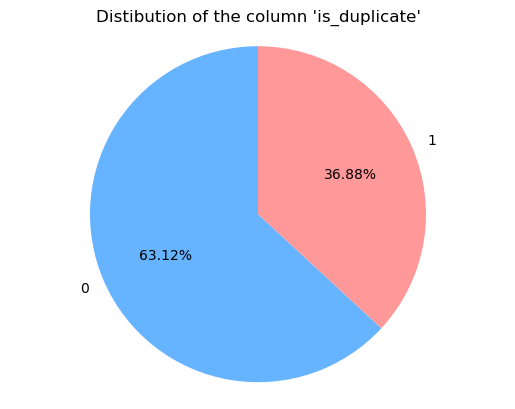

In [9]:
import matplotlib.pyplot as plt

counts = quora_df['is_duplicate'].value_counts()

colors = ['#66b3ff', '#ff9999']

plt.pie(
    counts, 
    labels=counts.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors
)

plt.title("Distibution of the column 'is_duplicate'")
plt.axis('equal')
plt.show()

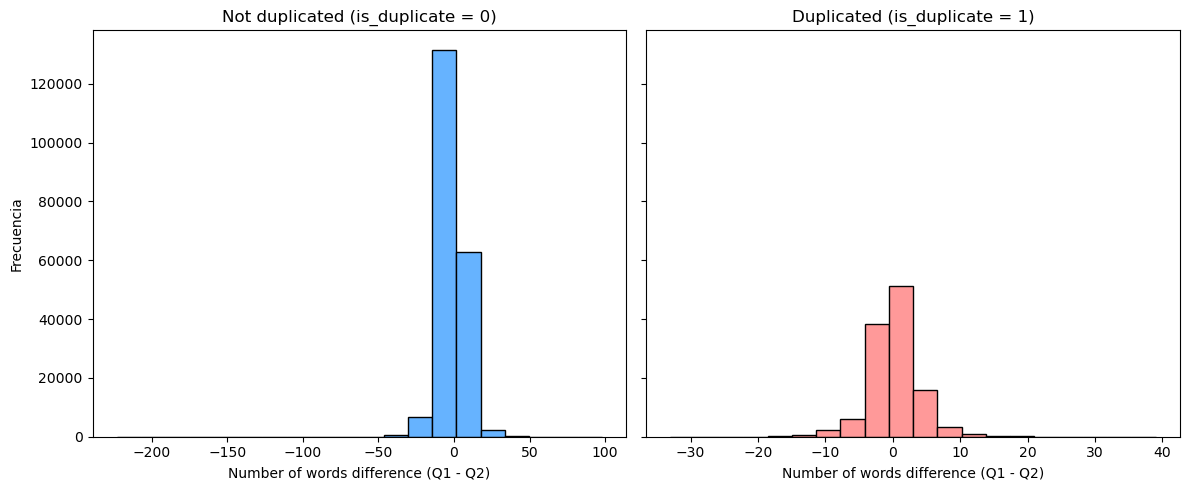

In [10]:
import matplotlib.pyplot as plt

copy_df = quora_df.copy()

copy_df['word_diff'] = copy_df['question1'].apply(lambda x: len(str(x).split())) - \
                       copy_df['question2'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ['#66b3ff', '#ff9999']

# Graph for is_duplicated = 0
axes[0].hist(copy_df[copy_df['is_duplicate'] == 0]['word_diff'], bins=20, color=colors[0], edgecolor='black')
axes[0].set_title('Not duplicated (is_duplicate = 0)')
axes[0].set_xlabel('Number of words difference (Q1 - Q2)')
axes[0].set_ylabel('Frecuencia')

# Graph for is_duplicated = 1
axes[1].hist(copy_df[copy_df['is_duplicate'] == 1]['word_diff'], bins=20, color=colors[1], edgecolor='black')
axes[1].set_title('Duplicated (is_duplicate = 1)')
axes[1].set_xlabel('Number of words difference (Q1 - Q2)')

plt.tight_layout()
plt.show()

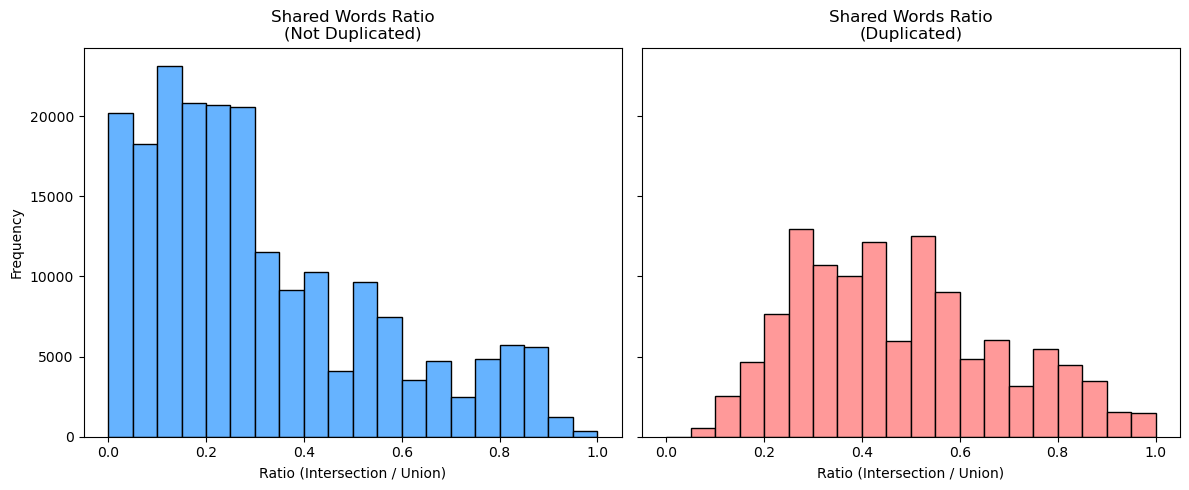

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# Create a copy to avoid modifying the original dataframe
copy_df = quora_df.copy()

# Pre-compile the regex pattern
word_pattern = re.compile(r'\w+')

# Jaccard Similarity = (Intersection of Words) / (Union of Words)
ratios = []
for q1, q2 in zip(copy_df['question1'], copy_df['question2']):
    set_q1 = set(word_pattern.findall(str(q1).lower()))
    set_q2 = set(word_pattern.findall(str(q2).lower()))
    
    # Calculate intersection and union
    intersection = len(set_q1 & set_q2)
    union = len(set_q1 | set_q2)
    
    # Avoid division by zero if both strings are empty or have no words
    if union == 0:
        ratio = 0
    else:
        ratio = intersection / union
        
    ratios.append(ratio)

copy_df['shared_words_ratio'] = ratios


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ['#66b3ff', '#ff9999']

# Histogram for is_duplicate = 0
# Ratios are always between 0.0 and 1.0, so bins=20 nicely divides it into 5% chunks
axes[0].hist(copy_df[copy_df['is_duplicate'] == 0]['shared_words_ratio'], 
             bins=20, range=(0, 1), color=colors[0], edgecolor='black')
axes[0].set_title('Shared Words Ratio\n(Not Duplicated)')
axes[0].set_xlabel('Ratio (Intersection / Union)')
axes[0].set_ylabel('Frequency')

# Histogram for is_duplicate = 1
axes[1].hist(copy_df[copy_df['is_duplicate'] == 1]['shared_words_ratio'], 
             bins=20, range=(0, 1), color=colors[1], edgecolor='black')
axes[1].set_title('Shared Words Ratio\n(Duplicated)')
axes[1].set_xlabel('Ratio (Intersection / Union)')

# Adjust layout
plt.tight_layout()
plt.show()

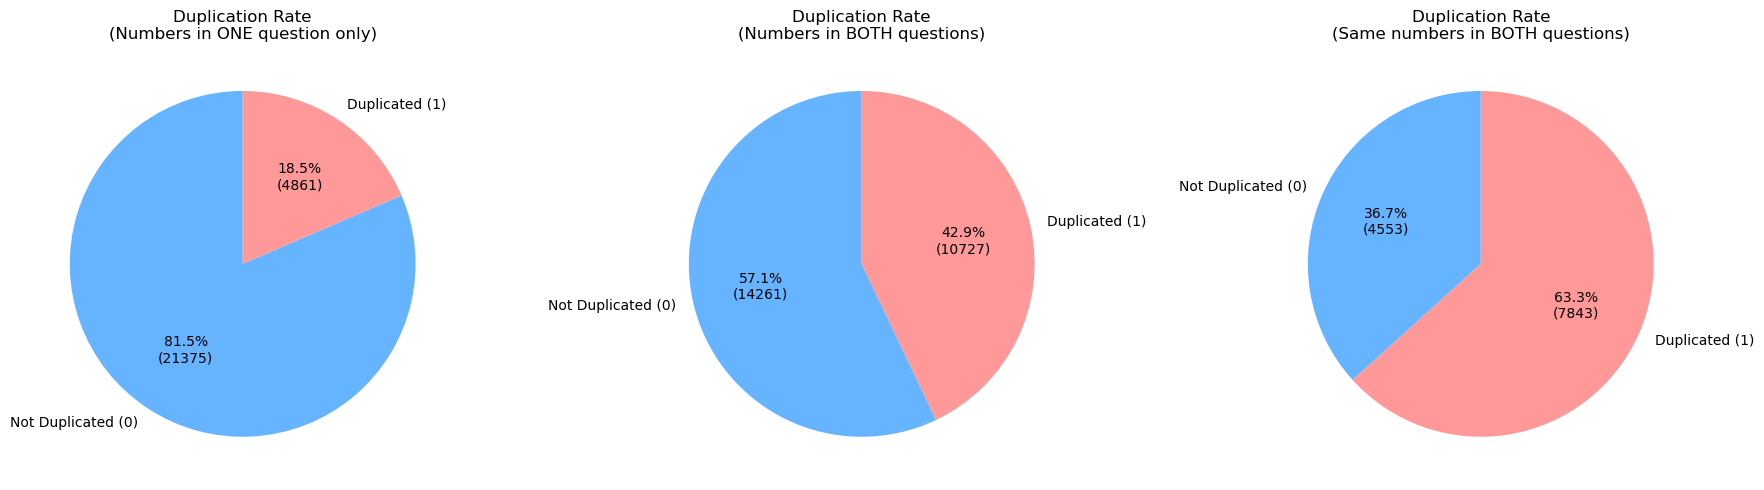

In [12]:
import matplotlib.pyplot as plt
import re

copy_df = quora_df.copy()

# Pre-compile the regex pattern and extract sets of numbers
number_pattern = re.compile(r'\d+')
copy_df['nums_q1'] = [set(number_pattern.findall(str(text))) for text in copy_df['question1']]
copy_df['nums_q2'] = [set(number_pattern.findall(str(text))) for text in copy_df['question2']]

# Calculate lengths using vectorized string operations
len_q1 = copy_df['nums_q1'].str.len()
len_q2 = copy_df['nums_q2'].str.len()

# Create boolean masks for our 3 specific conditions
# - Condition 1: Numbers in only one of the questions (XOR logic)
mask_only_one = ((len_q1 > 0) & (len_q2 == 0)) | ((len_q1 == 0) & (len_q2 > 0))

# - Condition 2: Numbers in both questions
mask_both = (len_q1 > 0) & (len_q2 > 0)

# - Condition 3: Numbers in both questions AND the exact same numbers
mask_both_same = mask_both & (copy_df['nums_q1'] == copy_df['nums_q2'])


# --- Custom function for autopct ---
# This closure captures the raw data values to calculate the absolute count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        # Calculate absolute value from percentage and total
        val = int(round(pct * total / 100.0))
        # Return formatted string: Percentage (Count)
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#66b3ff', '#ff9999']

# Define colors for Not Duplicated (0) and Duplicated (1)
labels_dup = ["Not Duplicated (0)", "Duplicated (1)"]

# --- PIE 1: Numbers in ONE question only ---
# .sort_index() ensures 0 is always first and 1 is second, keeping colors consistent
dist_only_one = copy_df[mask_only_one]['is_duplicate'].value_counts().sort_index()
axes[0].pie(dist_only_one, labels=labels_dup, autopct=make_autopct(dist_only_one), colors=colors, startangle=90)
axes[0].set_title('Duplication Rate\n(Numbers in ONE question only)')

# --- PIE 2: Numbers in BOTH questions ---
dist_both = copy_df[mask_both]['is_duplicate'].value_counts().sort_index()
axes[1].pie(dist_both, labels=labels_dup, autopct=make_autopct(dist_both), colors=colors, startangle=90)
axes[1].set_title('Duplication Rate\n(Numbers in BOTH questions)')

# --- PIE 3: Same numbers in BOTH questions ---
dist_both_same = copy_df[mask_both_same]['is_duplicate'].value_counts().sort_index()
axes[2].pie(dist_both_same, labels=labels_dup, autopct=make_autopct(dist_both_same), colors=colors, startangle=90)
axes[2].set_title('Duplication Rate\n(Same numbers in BOTH questions)')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

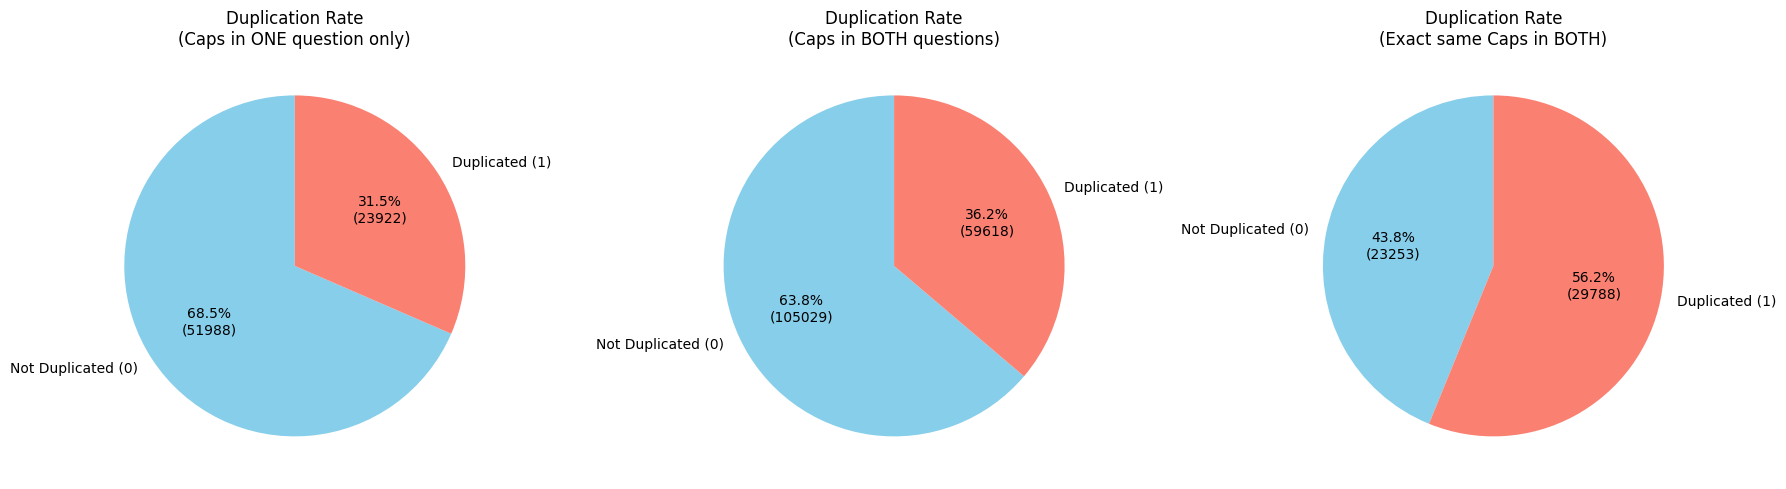

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# Create a copy to avoid modifying the original dataframe
copy_df = quora_df.copy()

# 1. Pre-compile regex to cleanly extract words
word_pattern = re.compile(r'\b\w+\b')

def get_capitalized_entities(text):
    words = word_pattern.findall(str(text))
    if len(words) < 2:
        return set()
    return {w for w in words[1:] if w[0].isupper()}

# 2. Extract sets using fast list comprehensions
caps_q1 = [get_capitalized_entities(text) for text in copy_df['question1']]
caps_q2 = [get_capitalized_entities(text) for text in copy_df['question2']]

# 3. Calculate lengths
len_q1 = np.array([len(s) for s in caps_q1])
len_q2 = np.array([len(s) for s in caps_q2])

caps_q1_series = pd.Series(caps_q1)
caps_q2_series = pd.Series(caps_q2)

# 4. Create boolean masks
mask_only_one = ((len_q1 > 0) & (len_q2 == 0)) | ((len_q1 == 0) & (len_q2 > 0))
mask_both = (len_q1 > 0) & (len_q2 > 0)
mask_both_same = mask_both & (caps_q1_series == caps_q2_series)

# --- Custom function for autopct ---
# This closure captures the raw data values to calculate the absolute count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        # Calculate absolute value from percentage and total
        val = int(round(pct * total / 100.0))
        # Return formatted string: Percentage (Count)
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

# 5. Plotting: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#66b3ff', '#ff9999']

target_col = 'is_duplicate'
labels_dup = ["Not Duplicated (0)", "Duplicated (1)"]

# --- PIE 1: Entities in ONE question only ---
dist_only_one = copy_df[mask_only_one][target_col].value_counts().sort_index()
axes[0].pie(dist_only_one, labels=labels_dup, 
            autopct=make_autopct(dist_only_one), # Apply custom function
            colors=colors, startangle=90)
axes[0].set_title('Duplication Rate\n(Caps in ONE question only)')

# --- PIE 2: Entities in BOTH questions ---
dist_both = copy_df[mask_both][target_col].value_counts().sort_index()
axes[1].pie(dist_both, labels=labels_dup, 
            autopct=make_autopct(dist_both), # Apply custom function
            colors=colors, startangle=90)
axes[1].set_title('Duplication Rate\n(Caps in BOTH questions)')

# --- PIE 3: Exact same entities in BOTH questions ---
dist_both_same = copy_df[mask_both_same][target_col].value_counts().sort_index()
axes[2].pie(dist_both_same, labels=labels_dup, 
            autopct=make_autopct(dist_both_same), # Apply custom function
            colors=colors, startangle=90)
axes[2].set_title('Duplication Rate\n(Exact same Caps in BOTH)')

# Adjust layout
plt.tight_layout()
plt.show()

## Data Splitting

In [3]:
A_df, test_df = train_test_split(
    quora_df, 
    test_size=0.05, 
    random_state=123
)

train_df, val_df = train_test_split(
    A_df, 
    test_size=0.05, 
    random_state=123
)    # Inicializamos el array con ceros

print(f'train_df.shape = {train_df.shape}')
print(f'val_df.shape = {val_df.shape}')
print(f'test_df.shape = {test_df.shape}')

train_df.shape = (291897, 6)
val_df.shape = (15363, 6)
test_df.shape = (16172, 6)


## Models

In [4]:
MODELS_DIR = "models"
ALREADY_TRAINED = os.path.exists(MODELS_DIR)

if not ALREADY_TRAINED:
    os.makedirs(MODELS_DIR)
    print(f"Created '{MODELS_DIR}/' — models will be trained and saved.")
else:
    print(f"'{MODELS_DIR}/' already exists — training will be skipped for any model already on disk.")

Created 'models/' — models will be trained and saved.


### Baseline model

In [5]:
CV_PATH       = os.path.join(MODELS_DIR, "count_vectorizer.pkl")
TFIDF_PATH    = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
BASELINE_PATH = os.path.join(MODELS_DIR, "baseline_logistic.pkl")

if (not os.path.exists(CV_PATH) or not os.path.exists(TFIDF_PATH)) and not os.path.exists(BASELINE_PATH):
    # Transform questions to strings (if not we may find some errors)
    q1_train =  utils.cast_list_as_strings(list(train_df["question1"]))
    q2_train =  utils.cast_list_as_strings(list(train_df["question2"]))

    # --- Fitting a Count Vectorizer ---
    if not os.path.exists(CV_PATH):
        count_vectorizer = sklearn.feature_extraction.text.CountVectorizer(ngram_range=(1,1))
        count_vectorizer.fit(q1_train + q2_train)

        utils.save_object(count_vectorizer, CV_PATH)
        print("Count Vectorizer trained and saved")
    else:
        count_vectorizer = utils.load_object(CV_PATH)
        print(f"Loading the Count Vectorizer from {CV_PATH}")
    

    # --- Fitting a TF-IDF ---
    if not os.path.exists(TFIDF_PATH):
        tfidf_vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(
            ngram_range=(1, 1), min_df=3, sublinear_tf=True
        )
        tfidf_vectorizer.fit(q1_train + q2_train)

        utils.save_object(tfidf_vectorizer, TFIDF_PATH)
        print("TF-IDF trained and saved")
    else:
        tfidf_vectorizer = utils.load_object(TFIDF_PATH)
        print(f"Loading the TF-IDF from {TFIDF_PATH}")

    X_tr_q1q2 = utils.get_combined_features(train_df, count_vectorizer=count_vectorizer, tfidf_vectorizer=tfidf_vectorizer)

    # --- Fitting a Logistic Regressor ---
    logistic = sklearn.linear_model.LogisticRegression(solver="liblinear", random_state=123)
    y_train = train_df["is_duplicate"].values
    logistic.fit(X_tr_q1q2, y_train)

    utils.save_object(logistic, BASELINE_PATH)
    print("Logistic Regressor trained and saved")
else:
    print("count_vectorizer.pkl, tfidf_vectorizer.pkl and baseline_logistic.pkl already exists — skipping.")

Count Vectorizer trained and saved
TF-IDF trained and saved
Logistic Regressor trained and saved


In [6]:
y_train = train_df["is_duplicate"].values

X_train = utils.get_combined_features(train_df, count_vectorizer, tfidf_vectorizer)
X_val   = utils.get_combined_features(val_df,   count_vectorizer, tfidf_vectorizer)

y_train = train_df["is_duplicate"].values
y_val   = val_df["is_duplicate"].values

rows = []

# Baseline model on all three splits
rows.append(utils.evaluate_model(logistic, X_train, y_train, "baseline", "train"))
rows.append(utils.evaluate_model(logistic, X_val,   y_val,   "baseline", "val"))

results_df = pd.DataFrame(rows)
display(results_df)

# Some examples of mistakes that the model makes on validation
mistake_indices, predictions = utils.get_mistakes(logistic, X_val, y_val)

utils.print_mistake_k(0, val_df, mistake_indices, predictions)
utils.print_mistake_k(9, val_df, mistake_indices, predictions)
utils.print_mistake_k(13, val_df, mistake_indices, predictions)
utils.print_mistake_k(19, val_df, mistake_indices, predictions)
utils.print_mistake_k(25, val_df, mistake_indices, predictions)


,model,split,roc_auc,precision,recall,f1,accuracy
0,baseline,train,0.9419,0.8167,0.8324,0.8245,0.8694
1,baseline,val,0.9007,0.7542,0.7662,0.7602,0.8216


Who is more dishonest, Donald Trump or Hillary Clinton?
Would you rather vote for Donald Trump or Hillary Clinton? Why?
true class: 0
prediction: 1

What are the pros and cons of using Python vs. Java?
What are the advantages and disadvantages of Python over Java?
true class: 1
prediction: 0

How would feminists depict a sex scene in a movie?
What is behind a sex scene in a movie?
true class: 0
prediction: 1

What is a good solar panel installation provider near Aptos, California CA?
What is a suitable solar panel installation provider near Aptos, California CA?
true class: 1
prediction: 0

How should I learn to code?
Should I learn how to code?
true class: 0
prediction: 1

